**Eurecom**
**Digital Communications**
Lab Session 2, December 2025

# Receiver Design for NR Secondary Synchronization Signals (SSS)
The goal of this lab session is to investigate the OFDM receivers for
the SSS signals used 3GPP-NR systems.  These are the second most basic signals that a terminal must detect prior to initiating a connection with the basestation. This detection is the second step in the so-called *cell search* procedure.

You are to hand-in a report answering all the questions outlined here along with corresponding python code and figure files by modifying this Notebook and pushing to a branch on EURECOM's gitlab repository for the course. In addition to the normal class sessions, you are expected to continue to work on your own time.

This document is just a complement of the slideset with specific instructions/questions for this lab session. 

## 5G NR OFDM Time/Frequency Allocations

An overview of the 5G NR OFDM time and frequency structure is shown in Figure 1. Signals are organized in so-called *radio frames* which are simply a 10ms period. The radio frame is subdivided in subframes of 1ms which are further subdivided into slots of duration $2^{-\mu}$ ms. $\mu=0,1,2,3,4,5,6$ is known as the numerology which defines the duration of slots and the so-called *subcarrier spacing (SCS)* which is the amount of spectrum corresponding to a single OFDM carrier. The SCS is given by $15\cdot 2^{\mu}$kHz. The most common numerologies are 

- 15kHz (same as 4G and used for systems below 2 GHz) with a 1ms slot/subframe
- 30kHz (main 5G configuration for systems from 2-6 GHz) with a 500$\mu$s slot (2 slots per subframe)
- 120kHz (main 5G configuration for systems above 24 GHz) with a 125$\mu$s slot (8 slots per subframe)

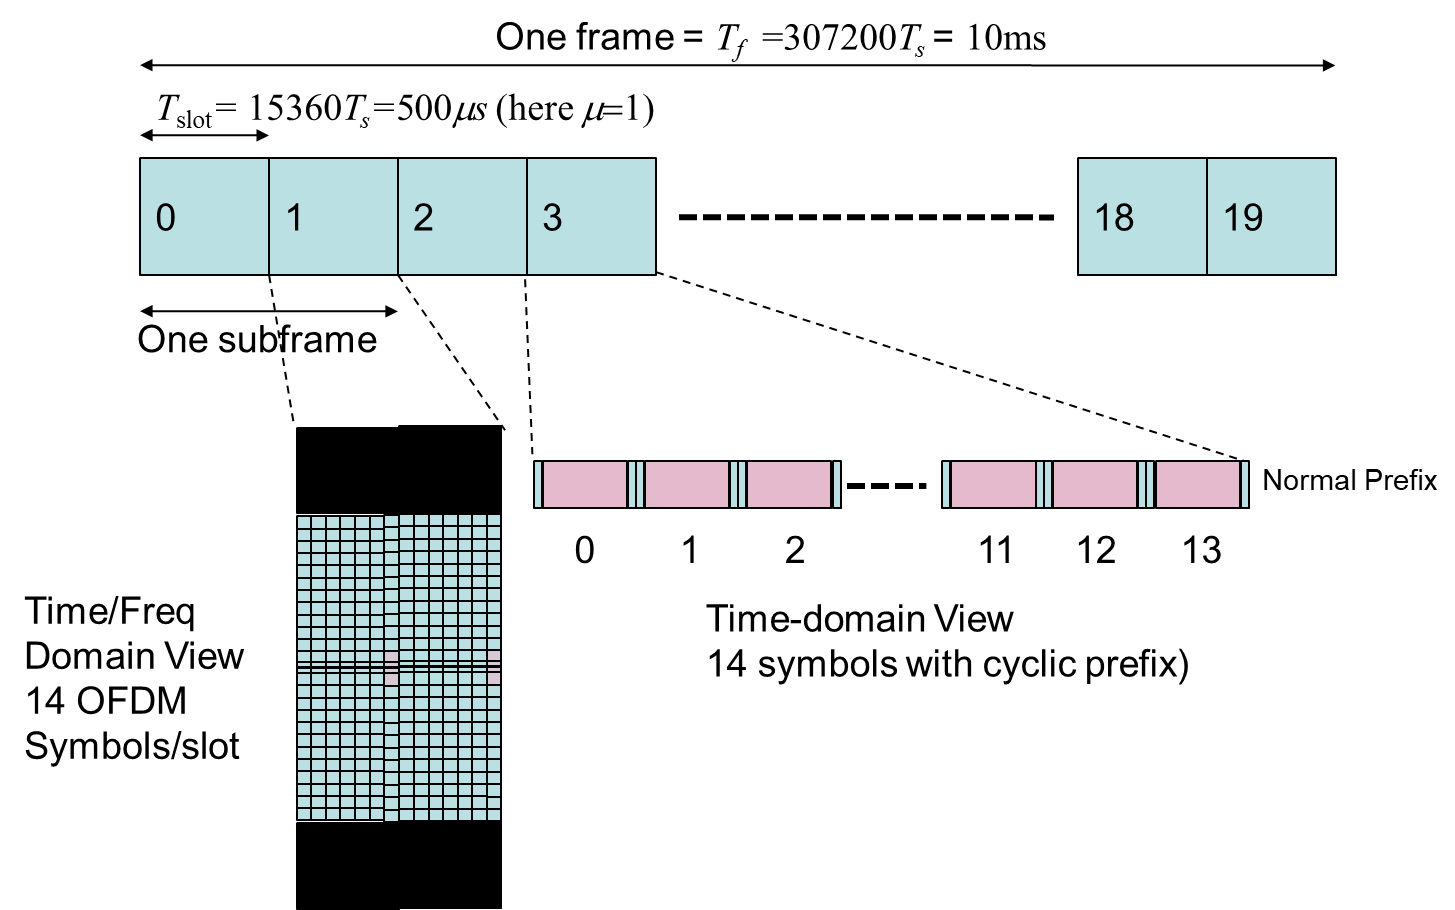
$$\text{Figure 1: 5G NR OFDM Time/Frequency Structure}$$

OFDM symbols have different sizes depdending on the total bandwidth and subcarrier-spacing. A selection of common formats are shown in Table 1. For the purpose of this lab session we use a 2048 point DFT ($N$) with up to $162\cdot 12$ subcarriers which can support 40,50,60 MHz cell bandwidths. In 5G NR the subcarrier is called a *resource element* and the basic granularity for allocating frequency-domain resources is a group of 12 resource elements known as the *physical resource block (PRB)*. 

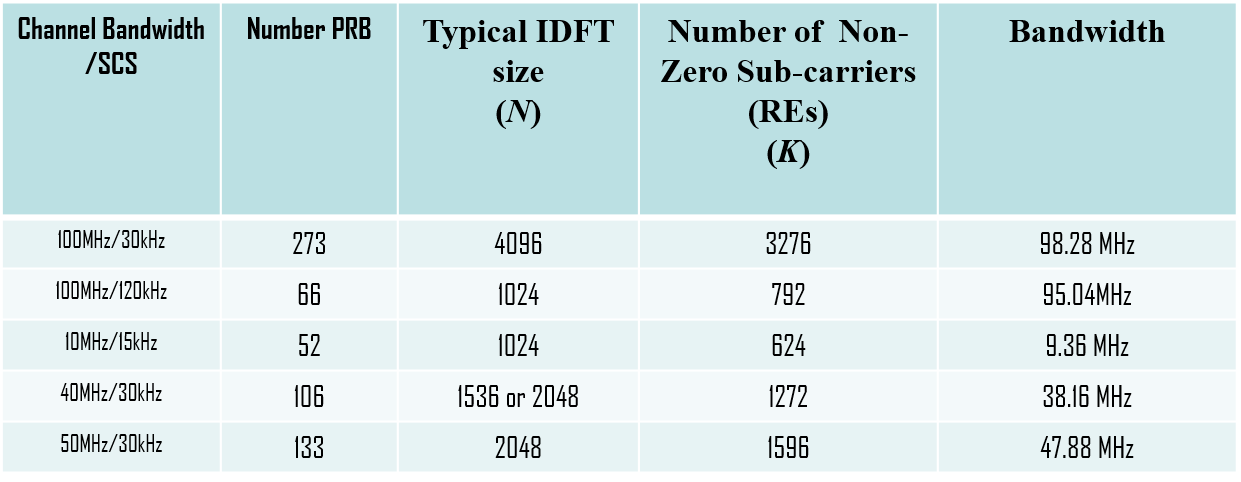
$$\text{Table 1: Some typical 5G NR OFDM Configurations}$$

## SSS signals
The SSS is an BPSK-modulated OFDM signal comprising 127 subcarriers in subcarriers 56-182 of symbol 2 in the so-called *SSB block*. The SSB Block comprises the PSS (from Lab Session 1), the SSS and the PBCH or *Physical Broadcast Channel*. The collection of the three messages in the SSB includes the minimal amount of information to identify a cell in the 5G system along with some basic parameters needed to detect the basic signaling channel of the 5G system (the *physical downlink control channel (PDCCH)* which allows for receiving downlink information from the basestation or *gNodeB*. The temporal position in the frame of the SSB block is determined from the position of the PSS that was detected in Lab Session 1. The time and frequency structure of the SS Block is shown in Figure 2.

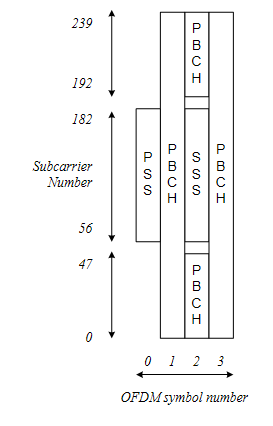
$$\text{Figure 2: 5G NR Synchronization Signal Block}$$

It comprises 4 OFDM symbols. The actual frequency-domain resource allocations in the symbols are shown in Figure 2.

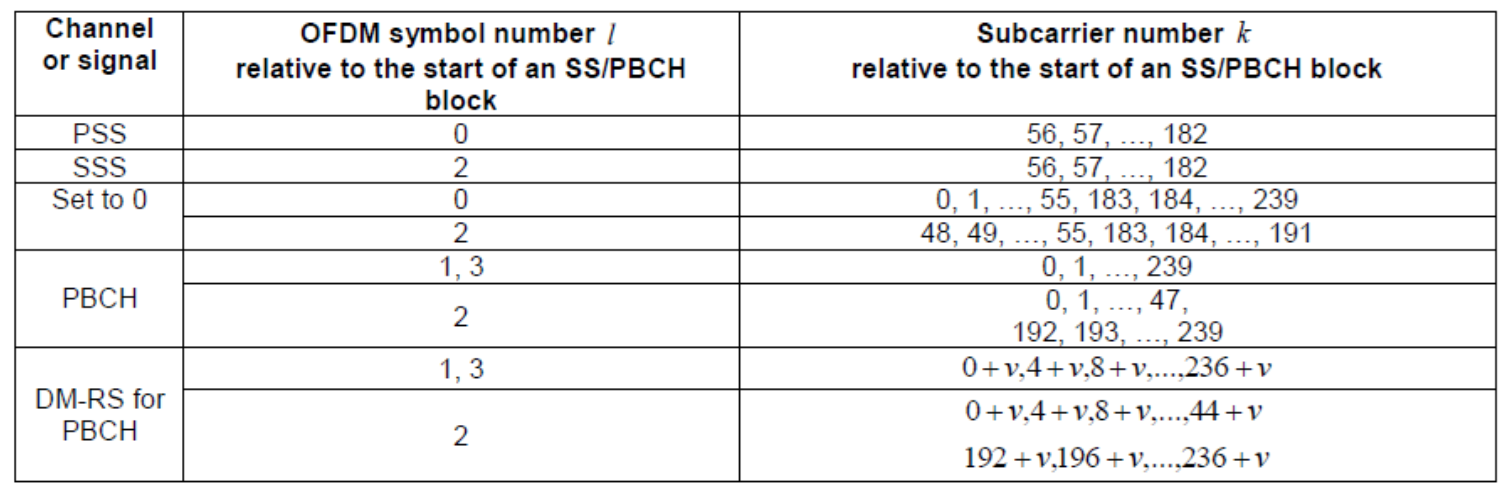
$$\text{Figure 3: 5G NR PSS/SSS/PBCH resource elements}$$

The SSB comprises 240 resource elements or 20 PRBs. The position of the SSB within the OFDM symbol is configurable but limited to the frequencies on the so-called *SSB Raster*, which for systems above 3 GHz is a multiple of 1.44 MHz. For the purpose of this lab session, the position will be given (in Lab Session 1 we had the parameter $\mathtt{k\_min}$ which controlled the frequency-domain location of the PSS signal). The determination is part of the cell search procedure since it is not known by the user terminal beforehand and can change from time to time in a given region. The position is usually specified by the frequency of the central subcarrier of the SSB.
 
We are concerned with complex baseband equivalent transmit signals as in lab session 1.
For all signals in this lab session, as in the first lab, the sampling rate is assumed to be 61.44 Msamples/s.  

### Steps and Questions

1. you will need the results of the first lab session, specifically the time-synchronization implementation and the signal files that you used before. If needed, we will acquire more signal files.
2. **OFDM demodulation**: extract the SSS symbol based on the timing information obtained from the PSS.  Remove the prefix and perform the FFTs of size 2048 to transfer them to the frequency domain.  

2a) Plot the complex modulus of the 127 resource elements corresponding to the SSS.  Verify that there is a strong signal component in these elements. Verify also that there is no signal in positions $48...55$ and $183...191$.  These are typically used by the receiver to estimate the noise/interference level since they are so-called DTX elements (discontinuous transmission).  Plot also the complex modulus of the entire OFDM symbol containing the SSS.  Can you see anything characteristic of a QAM OFDM signal?

2b) Plot the I/Q constellation of the 127 SSS elements.  Explain (in words) what you see and why.

2c) Extract also the frequency-domain representation of the PSS signal which is in the same positions as the SSS but in symbol 0 of the SSB block.  Use the supplied (frequency-domain now, not time-domain like in the first lab) PSS waveform to perform least-squares channel estimation, namely:
\begin{equation}
\mathbf{H_{\mathrm PSS}} = \mathbf{PSS}_i^* \odot {\mathbf R}_{\mathrm{PSS}}
\end{equation}
where $\mathbf{PSS_i}$ is the frequency-domain representation of the $i^{\mathrm{th}}$ PSS signal and ${\mathbf R}_{\mathrm{PSS}}$ is the frequency-domain received signal of the PSS symbol.  Show that this is a good estimator for the channel-response by looking at the complex modulus of the frequency and time-domain responses (plot the complex modulus IFFT of the 127-point estimate.  You should see a single strong peak and perhaps a bit more ...

2d) Derive the Maximum-Likelihood receiver assuming that the channel does not vary and is just a complex phase-shift (i.e. the classical non-coherent channel model we studied) and that the PSS signal is known perfectly. Relate this to the channel estimator we considered in the previous step.
\item consider also a channel model which is of the form $H_n(k) = e^{j2\pi(\phi + k\alpha) + n\beta}$ where $\alpha$ and $\beta$ are unnkown constants and limited to $-\alpha_0\leq\alpha\leq\alpha_0$, $-\beta_0\leq\beta\leq\beta_0$ and $\alpha_0,\beta_0$ are small quantities. $n$ represents the symbol index within the SSB block, where $n=0$ for PSS, $n=2$ for SSS. The other values for $n$ are not needed for the PSS/SSS detection. Think of what we did in Lab session 1 with an unknown frequency offset. Can you suggest a method to quantize $\alpha,\beta$ to derive a hypothesis testing problem which will lead to a practical receiver structure. $\alpha$ and $\beta$ are related to residual timing and frequency errors from the PSS detection component (i.e. the errors in estimating $N_f$ and $\Delta f$. Explain. 

2e) Use this channel estimate with potential smoothing (interpolation) to compensate the signal of the SSS.  Plot the I/Q signal at the output of the channel compensation.  Verify that you see something like an antipodal signal.  It may be distorted due to a non-flat frequency response. 

3. **Data detection**: Now use the supplied routine below to perform the data detection by doing a correlation of the 336 BPSK sequences to find the one with the highest correlation.



In [2]:
import numpy as np

def nr_sss(N_ID1: int,N_ID2: int) -> np.ndarray:
    """
    5G NR SSS per 3GPP TS 38.211 §7.4.2.3
      - Length 127, BPSK in {+1, -1}
      - 2 m-seq (degree-7, poly1 x^7 + x^4 + 1, poly2 x^7 + x + 1), init state = 0000001 on both
      - cyclic shifts by m0 = 15*floor(N_ID1/112) + 5*N_ID2, m1 = N_ID1%112

    Returns: float32 array of shape (127,) with values in {+1, -1}
    """
    if N_ID2 not in (0, 1, 2):
        raise ValueError("N_ID2 must be 0, 1, or 2")
    if (N_ID1 < 0) or (N_ID1 > 335):
        raise ValueError("N_ID1 must be 0...335")
        
    # LFSR state s[0..6], spec init: 0 0 0 0 0 0 0
    s0 = np.array([0,0,0,0,0,0,1], dtype=np.uint8)
    s1 = np.array([0,0,0,0,0,0,1], dtype=np.uint8)

    # Generate base m-sequence c(n), n=0..126
   
    c0 = np.empty(127, dtype=np.uint8)
    c1 = np.empty(127, dtype=np.uint8)

    for n in range(6):
        c0[n] = s0[n]
        c1[n] = s1[n]

    for n in range(120):
        c0[n+7] = c0[n] ^ c0[n+4]
        c1[n+7] = c1[n] ^ c1[n+1]
        
    # Apply cyclic shift (43*N_ID2), d(n) = c(n + 43*N_ID2 mod 127)
    m0 = 15 * (N_ID1//112) + 5*N_ID2
    m1 = N_ID1 % 112
    
    d0_bin = np.roll(c0, -m0)
    d1_bin = np.roll(c1, -m1)
    
    # Map to BPSK: 0 -> +1, 1 -> -1
    d = (1 - 2*d0_bin.astype(np.int8)).astype(np.float32) * (1 - 2*d1_bin.astype(np.int8)).astype(np.float32)
    return d


# --- Build time-domain OFDM symbol and add CP (length Ncp) ---
def sss_time_domain(N_ID1: int, N_ID2: int, Nfft: int = 2048, Ncp: int = 144, k_min: int = -63):
    sss = nr_pss(N_ID1,N_ID2)
    X = map_pss_to_fft_bins(pss, Nfft, k_min)
    x_td = np.fft.ifft(X).astype(np.complex64)      # no fftshift anywhere
    x_cp = np.concatenate([x_td[-Ncp:], x_td])      # prepend cyclic prefix
    return x_cp



4.  **Cell ID**: Obtain the most-likely Cell Id by combining the PSS and SSS sequences. 